# P05: World Model Evaluation Dashboard

Load the P03 Dreamer and P04 Transformer checkpoints, evaluate them on held-out episodes, and compare the P04 metrics side by side. The dashboard is intentionally conservative: it prefers explicit checkpoint loading and honest fallback behavior over hidden assumptions.

**Prerequisite**: P03 (`dreamer.pt`) and P04 (`transformer_wm.pt`) if present; otherwise each missing checkpoint falls back to a randomly initialized model so the notebook still runs as a smoke test. The reported metrics are only meaningful with the pretrained checkpoints, so the ship-ready path is the loaded-checkpoint path.

**Metrics**: Dreamer reward correlation, PSNR, latent drift; Transformer token loss, PSNR, latent drift.

> Notebook source: [p05_evaluation_dashboard.ipynb](https://github.com/datawhalechina/learn-world-model/blob/main/docs/en/projects/p05_evaluation_dashboard.ipynb)

In [1]:
# Install dependencies for a fresh environment.
!pip install torch torchvision matplotlib numpy


With the environment ready, import the trajectory-generation and scoring utilities used throughout the dashboard.

In [ ]:
import math
from pathlib import Path

try:
    from IPython import get_ipython
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
np.random.seed(42)
try:
    import torch_xla.core.xla_model as xm
    _XLA_AVAILABLE = True
except Exception:
    xm = None
    _XLA_AVAILABLE = False


def _resolve_device():
    if _XLA_AVAILABLE:
        return xm.xla_device()
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


DEVICE = _resolve_device()
USE_TPU = DEVICE.type == 'xla'
USE_CUDA = DEVICE.type == 'cuda'
LOAD_DEVICE = torch.device('cpu') if USE_TPU else DEVICE


def optimizer_step(optimizer, scaler=None):
    if USE_TPU:
        xm.optimizer_step(optimizer)
    elif scaler is not None:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

# Shared hyperparameters -- must match P03 and P04
HIDDEN_DIM   = 128   # GRU / Transformer d_model
LATENT_DIM   = 32    # stochastic state dim (RSSM) / embedding dim
N_CATEGORIES = 32    # CatVAE discrete vocabulary
N_ACTIONS    = 2
SEQ_LEN      = 20    # trajectory horizon
N_EVAL_TRAJ  = 20    # held-out episodes
ROLLOUT_LEN  = 10    # steps used for horizon metrics

NOTEBOOKS_DIR = Path('.')
DREAMER_CKPT  = NOTEBOOKS_DIR / 'dreamer.pt'
TRANS_CKPT    = NOTEBOOKS_DIR / 'transformer_wm.pt'

print('Device:', DEVICE)
if USE_TPU:
    print('TPU backend    : torch_xla')
print('PyTorch version:', torch.__version__)
print('Dreamer checkpoint exists:', DREAMER_CKPT.exists())
print('Transformer checkpoint exists:', TRANS_CKPT.exists())

Device: cuda
PyTorch version: 2.11.0+cu128
Dreamer checkpoint exists: True
Transformer checkpoint exists: True


## 1. Synthetic Environment and Trajectory Generation

Generate 20 held-out episodes from the same environment used in P03.

In [3]:
class SyntheticEnv:
    """Moving red circle on a 64x64 canvas. Two actions: right (0) or left (1)."""
    SIZE = 64
    RADIUS = 8

    def __init__(self, seed=None):
        self.rng = np.random.RandomState(seed)
        self.cx = self.cy = self.SIZE // 2

    def reset(self):
        self.cx = self.rng.randint(20, self.SIZE - 20)
        self.cy = self.rng.randint(20, self.SIZE - 20)
        return self._obs()

    def step(self, action):
        self.cx = int(np.clip(self.cx + (4 if action == 0 else -4), 10, self.SIZE - 10))
        reward = 1.0 if self.cx > self.SIZE // 2 else 0.0
        return self._obs(), reward, False

    def _obs(self):
        img = np.zeros((3, self.SIZE, self.SIZE), dtype=np.float32)
        color = np.array([0.9, 0.3, 0.3], dtype=np.float32)
        cx, cy, r = self.cx, self.cy, self.RADIUS
        for y in range(self.SIZE):
            for x in range(self.SIZE):
                if (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2:
                    img[:, y, x] = color
        return img


def generate_eval_trajectories(n_traj=N_EVAL_TRAJ, horizon=SEQ_LEN, base_seed=999):
    """Generate held-out trajectories not seen during training."""
    obs_list, act_list, rew_list = [], [], []
    for i in range(n_traj):
        env = SyntheticEnv(seed=base_seed + i)
        obs = env.reset()
        traj_obs, traj_act, traj_rew = [obs], [], []
        rng = np.random.RandomState(base_seed + i + 10000)
        for _ in range(horizon):
            action = rng.randint(0, N_ACTIONS)
            next_obs, rew, _ = env.step(action)
            traj_act.append(action)
            traj_rew.append(rew)
            traj_obs.append(next_obs)
        # obs_seq has horizon+1 frames; we keep the first horizon as input
        obs_list.append(traj_obs[:horizon])
        act_list.append(traj_act)
        rew_list.append(traj_rew)
    obs_t = torch.tensor(np.array(obs_list), dtype=torch.float32)  # (N, T, 3, 64, 64)
    act_t = torch.tensor(np.array(act_list), dtype=torch.long)      # (N, T)
    rew_t = torch.tensor(np.array(rew_list), dtype=torch.float32)  # (N, T)
    return obs_t, act_t, rew_t


print(f'Generating {N_EVAL_TRAJ} held-out evaluation trajectories ({SEQ_LEN} steps each)...')
eval_obs, eval_act, eval_rew = generate_eval_trajectories()
print('eval_obs :', eval_obs.shape)
print('eval_act :', eval_act.shape)
print('eval_rew :', eval_rew.shape)
print('Reward mean (should be ~0.5):', eval_rew.mean().item())

Generating 20 held-out evaluation trajectories (20 steps each)...
eval_obs : torch.Size([20, 20, 3, 64, 64])
eval_act : torch.Size([20, 20])
eval_rew : torch.Size([20, 20])
Reward mean (should be ~0.5): 0.375


## 2. Model Architecture Definitions

Define the Dreamer and Transformer components inline so the dashboard is self-contained.

All classes are defined inline so this notebook is self-contained. The architecture
dimensions exactly match P03 and P04:

- `HIDDEN_DIM = 128`, `LATENT_DIM = 32`, `N_CATEGORIES = 32`
- **Dreamer side:** CNN VAE encoder/decoder, RSSM (GRU + prior/posterior nets), Actor, Critic
- **Transformer side:** CatVAE (same as P04), CausalTransformerWM (same as P04)

In [4]:
# Dreamer components.

class Encoder(nn.Module):
    """CNN encoder: 3x64x64 frame -> LATENT_DIM-dim mean and log-var."""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),    # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),   # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  # 8x8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), # 4x4
            nn.ReLU(),
            nn.Flatten(),                  # 256*4*4 = 4096
        )
        self.fc_mu     = nn.Linear(4096, latent_dim)
        self.fc_logvar = nn.Linear(4096, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def encode(self, x):
        mu, logvar = self.forward(x)
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)


class Decoder(nn.Module):
    """Transposed-CNN decoder: (HIDDEN_DIM + LATENT_DIM) -> 3x64x64."""
    def __init__(self, in_dim=HIDDEN_DIM + LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(in_dim, 256 * 4 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    # 64x64
            nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.fc(x).view(-1, 256, 4, 4)
        return self.net(h)


class RSSM(nn.Module):
    """Recurrent State-Space Model with deterministic (h) and stochastic (s) states."""
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, n_actions=N_ACTIONS):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.gru = nn.GRUCell(latent_dim + 1, hidden_dim)
        self.prior_net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, latent_dim * 2)
        )
        self.post_net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim, hidden_dim), nn.ELU(),
            nn.Linear(hidden_dim, latent_dim * 2)
        )
        self.recon = nn.Linear(latent_dim, latent_dim)

    def _action_feature(self, action):
        if action.dim() == 0:
            action = action.view(1, 1)
        elif action.dim() == 1:
            action = action.unsqueeze(-1)
        if action.shape[-1] > 1:
            action = action[..., 1:2]
        return action.float()

    def initial_state(self, batch_size):
        h = torch.zeros(batch_size, self.hidden_dim, device=DEVICE)
        s = torch.zeros(batch_size, self.latent_dim, device=DEVICE)
        return h, s

    def prior(self, h):
        mu, lv = self.prior_net(h).chunk(2, dim=-1)
        std = F.softplus(lv) + 0.1
        s = mu + std * torch.randn_like(std)
        return s, mu, std

    def posterior(self, h, z_obs):
        mu, lv = self.post_net(torch.cat([h, z_obs], dim=-1)).chunk(2, dim=-1)
        std = F.softplus(lv) + 0.1
        s = mu + std * torch.randn_like(std)
        return s, mu, std

    def prior_step(self, h, a):
        s, _, _ = self.prior(h)
        a_feat = self._action_feature(a)
        h_next = self.gru(torch.cat([s, a_feat], dim=-1), h)
        return s, h_next

    def posterior_step(self, h, a, z_obs):
        s, _, _ = self.posterior(h, z_obs)
        a_feat = self._action_feature(a)
        h_next = self.gru(torch.cat([s, a_feat], dim=-1), h)
        return s, h_next


class RewardModel(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, n_actions=N_ACTIONS, ac_hidden=128):
        super().__init__()
        self.n_actions = n_actions
        self.net = nn.Sequential(
            nn.Linear(hidden_dim + latent_dim + n_actions, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden),
            nn.ELU(),
            nn.Linear(ac_hidden, 1)
        )

    def _one_hot(self, action):
        if action.dim() == 0:
            action = action.view(1)
        if action.dim() == 1 and action.dtype != torch.float32:
            action = F.one_hot(action.long(), num_classes=self.n_actions).float()
        elif action.dim() == 1:
            action = action.unsqueeze(-1)
        elif action.dim() == 2 and action.shape[-1] == 1:
            action = F.one_hot(action.squeeze(-1).long(), num_classes=self.n_actions).float()
        return action.float()

    def forward(self, h, s, a):
        a_oh = self._one_hot(a)
        return self.net(torch.cat([h, s, a_oh], dim=-1)).squeeze(-1)


class Actor(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, action_dim=N_ACTIONS, ac_hidden=128, obs_feat_dim=1):
        super().__init__()
        inp = hidden_dim + latent_dim + obs_feat_dim
        self.net = nn.Sequential(
            nn.Linear(inp, ac_hidden), nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden), nn.ELU(),
            nn.Linear(ac_hidden, action_dim)
        )

    def forward(self, h, s, bar_pos=0.0):
        if not torch.is_tensor(bar_pos):
            bar_pos = torch.full((h.shape[0], 1), float(bar_pos), device=h.device)
        elif bar_pos.dim() == 0:
            bar_pos = bar_pos.view(1, 1).expand(h.shape[0], 1)
        elif bar_pos.dim() == 1:
            bar_pos = bar_pos.unsqueeze(-1)
        return self.net(torch.cat([h, s, bar_pos], -1))


class Critic(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, ac_hidden=128):
        super().__init__()
        inp = hidden_dim + latent_dim
        self.net = nn.Sequential(
            nn.Linear(inp, ac_hidden), nn.ELU(),
            nn.Linear(ac_hidden, ac_hidden), nn.ELU(),
            nn.Linear(ac_hidden, 1)
        )

    def forward(self, h, s):
        return self.net(torch.cat([h, s], -1)).squeeze(-1)


print('Dreamer architecture classes defined.')
print(f'  RSSM hidden_dim={HIDDEN_DIM}, latent_dim={LATENT_DIM}')

Dreamer architecture classes defined.
  RSSM hidden_dim=128, latent_dim=32


Now that the Dreamer stack is defined, add the Transformer world-model components so the dashboard can compare them directly.

In [5]:
# Transformer-based world model components.

def straight_through_gumbel(logits, tau=1.0):
    y_soft = F.gumbel_softmax(logits, tau=tau, hard=False)
    y_hard = F.one_hot(y_soft.argmax(-1), num_classes=logits.shape[-1]).float()
    return (y_hard - y_soft).detach() + y_soft


class CatVAEEncoder(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_categories),
        )

    def forward(self, x):
        return self.net(x)


class CatVAEDecoder(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(num_categories, 256),
            nn.ReLU(),
            nn.Linear(256, 256 * 4 * 4),
            nn.ReLU(),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid(),
        )

    def forward(self, z_onehot):
        h = self.fc(z_onehot).view(-1, 256, 4, 4)
        return self.deconv(h)


class CatVAE(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES, tau=1.0):
        super().__init__()
        self.encoder = CatVAEEncoder(num_categories)
        self.decoder = CatVAEDecoder(num_categories)
        self.tau = tau

    def encode(self, x):
        logits = self.encoder(x)
        z = straight_through_gumbel(logits, tau=self.tau)
        idx = logits.argmax(-1)
        return z, idx, logits

    def forward(self, x):
        z, idx, logits = self.encode(x)
        return self.decoder(z), z, idx, logits


class CausalTransformerWM(nn.Module):
    def __init__(self, num_categories=N_CATEGORIES, d_model=HIDDEN_DIM,
                 n_heads=4, n_layers=2, n_actions=N_ACTIONS, max_len=SEQ_LEN):
        super().__init__()
        self.d_model = d_model
        self.num_categories = num_categories
        self.z_proj   = nn.Linear(num_categories, d_model)
        self.a_embed  = nn.Embedding(n_actions, d_model)
        pos = torch.arange(max_len * 2).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe  = torch.zeros(max_len * 2, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads,
                dim_feedforward=d_model * 4,
                batch_first=True, norm_first=True
            ) for _ in range(n_layers)
        ])
        self.token_head  = nn.Linear(d_model, num_categories)
        self.reward_head = nn.Linear(d_model, 1)
        self.done_head   = nn.Linear(d_model, 1)

    def _causal_mask(self, T):
        return torch.triu(torch.ones(T, T, device=self.pe.device), diagonal=1).bool()

    def forward(self, z_seq, a_seq):
        B, T, _ = z_seq.shape
        z_emb = self.z_proj(z_seq)
        a_emb = self.a_embed(a_seq)
        tokens = torch.stack([z_emb, a_emb], dim=2).view(B, 2 * T, self.d_model)
        tokens = tokens + self.pe[:2 * T].unsqueeze(0)
        mask = self._causal_mask(2 * T)
        h = tokens
        for layer in self.layers:
            h = layer(h, src_mask=mask, is_causal=False)
        z_h = h[:, 0::2, :]
        return self.token_head(z_h), self.reward_head(z_h), self.done_head(z_h)


print('Transformer architecture classes defined.')
print(f'  CausalTransformerWM d_model={HIDDEN_DIM}, n_categories={N_CATEGORIES}')

Transformer architecture classes defined.
  CausalTransformerWM d_model=128, n_categories=32


## 3. Load or Initialize Both Models

Load checkpoints when available, otherwise fall back to random weights.

In [6]:
# Build model instances.
encoder      = Encoder(LATENT_DIM).to(DEVICE)
decoder      = Decoder(HIDDEN_DIM + LATENT_DIM).to(DEVICE)
rssm         = RSSM(LATENT_DIM, HIDDEN_DIM, N_ACTIONS).to(DEVICE)
reward_model = RewardModel(LATENT_DIM, HIDDEN_DIM, N_ACTIONS).to(DEVICE)
actor        = Actor(LATENT_DIM, HIDDEN_DIM, N_ACTIONS).to(DEVICE)
critic       = Critic(LATENT_DIM, HIDDEN_DIM).to(DEVICE)

catvae       = CatVAE(N_CATEGORIES).to(DEVICE)
transformer  = CausalTransformerWM().to(DEVICE)

dreamer_loaded = False
trans_loaded   = False

# Load Dreamer checkpoint (P03).
if DREAMER_CKPT.exists():
    try:
        ckpt = torch.load(DREAMER_CKPT, map_location=DEVICE, weights_only=False)
        if isinstance(ckpt, dict):
            if 'encoder' in ckpt:
                enc_state = {k.replace('conv.', 'net.'): v for k, v in ckpt['encoder'].items()}
                encoder.load_state_dict(enc_state, strict=True)
            if 'decoder' in ckpt:
                dec_state = {k.replace('deconv.', 'net.'): v for k, v in ckpt['decoder'].items()}
                decoder.load_state_dict(dec_state, strict=True)
            if 'rssm' in ckpt:
                rssm.load_state_dict(ckpt['rssm'], strict=True)
            if 'reward_model' in ckpt:
                reward_model.load_state_dict(ckpt['reward_model'], strict=True)
            if 'actor' in ckpt:
                actor.load_state_dict(ckpt['actor'], strict=True)
            if 'critic' in ckpt:
                critic.load_state_dict(ckpt['critic'], strict=True)
        dreamer_loaded = True
        print(f'Loaded Dreamer checkpoint from {DREAMER_CKPT}')
    except Exception as e:
        print(f'Could not load Dreamer checkpoint ({e}). Using random initialization.')
else:
    print('dreamer.pt not found. Using randomly initialized Dreamer.')

# Load Transformer checkpoint (P04).
if TRANS_CKPT.exists():
    try:
        ckpt = torch.load(TRANS_CKPT, map_location=DEVICE, weights_only=False)
        if isinstance(ckpt, dict):
            if 'catvae' in ckpt:
                catvae.load_state_dict(ckpt['catvae'], strict=True)
            if 'transformer_wm' in ckpt:
                transformer.load_state_dict(ckpt['transformer_wm'], strict=True)
        trans_loaded = True
        print(f'Loaded Transformer checkpoint from {TRANS_CKPT}')
    except Exception as e:
        print(f'Could not load Transformer checkpoint ({e}). Using random initialization.')
else:
    print('transformer_wm.pt not found. Using randomly initialized Transformer.')

# --- Freeze all parameters ---
for m in [encoder, decoder, rssm, reward_model, actor, critic, catvae, transformer]:
    m.eval()
    for p in m.parameters():
        p.requires_grad_(False)

print()
print(f'Dreamer loaded from checkpoint : {dreamer_loaded}')
print(f'Transformer loaded from checkpoint: {trans_loaded}')
print('All models frozen in eval mode.')

Loaded Dreamer checkpoint from dreamer.pt
Loaded Transformer checkpoint from transformer_wm.pt

Dreamer loaded from checkpoint : True
Transformer loaded from checkpoint: True
All models frozen in eval mode.


## 4. Per-Model Metric Computation

Compute the held-out metrics for each model.

We define helper functions for each metric, then loop over the 20 held-out trajectories.

**PSNR** measures pixel-level reconstruction fidelity; higher is better.
**Latent drift** (L2 distance between imagined and observed latent vectors) quantifies how
quickly the imagined trajectory diverges from reality.
**Reward correlation** (Pearson rho) checks whether the RSSM can predict which steps
yield reward, even under imagination.
**Token prediction loss** (cross-entropy) is the Transformer's training signal at test time.

In [7]:
def psnr_fn(pred, target):
    """Peak Signal-to-Noise Ratio in dB. Both tensors in [0,1]."""
    mse = F.mse_loss(pred.clamp(0, 1), target.clamp(0, 1))
    return 10.0 * torch.log10(1.0 / (mse + 1e-8)).item()


def pearson_rho(x, y):
    """Pearson correlation between 1-D tensors."""
    x = x - x.mean()
    y = y - y.mean()
    denom = (x.norm() * y.norm()).clamp(min=1e-8)
    return (x @ y / denom).item()


PSNR_STEPS   = [1, 3, 5, 10]
DRIFT_STEPS  = list(range(1, ROLLOUT_LEN + 1))

print('Utility functions defined.')
print('PSNR evaluation steps :', PSNR_STEPS)
print('Latent drift steps     :', DRIFT_STEPS)

Utility functions defined.
PSNR evaluation steps : [1, 3, 5, 10]
Latent drift steps     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


With the shared metric helper ready, compute the Dreamer rollout statistics first.

In [8]:
# Dreamer metrics.

dreamer_psnr        = {s: [] for s in PSNR_STEPS}
dreamer_drift       = {s: [] for s in DRIFT_STEPS}
dreamer_rew_corr    = []

with torch.no_grad():
    for traj_i in range(N_EVAL_TRAJ):
        obs_seq = eval_obs[traj_i].to(DEVICE)   # (T, 3, 64, 64)
        act_seq = eval_act[traj_i].to(DEVICE)   # (T,)
        rew_seq = eval_rew[traj_i].to(DEVICE)   # (T,)
        T = obs_seq.shape[0]

        # Encode all observations to get ground-truth latent vectors
        mu_all, _ = encoder(obs_seq)             # (T, LATENT_DIM)

        # Initialize RSSM state from first observation (posterior)
        h = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
        z0, _ = encoder.forward(obs_seq[0:1])    # mu as point estimate
        z0 = z0  # (1, LATENT_DIM)

        # 10-step imagination rollout starting from step 0
        imagined_rewards = []
        imagined_latents = []   # s at each step
        imagined_frames  = []

        h_cur = h.clone()
        s_cur = z0.clone()      # start stochastic state = encoded obs[0]

        for t in range(ROLLOUT_LEN):
            a_t = act_seq[t:t+1]
            s_next, h_next = rssm.prior_step(h_cur, a_t)
            r_pred = reward_model(h_next, s_next, a_t)   # scalar
            imagined_rewards.append(r_pred.squeeze())
            imagined_latents.append(s_next.squeeze(0))     # (LATENT_DIM,)
            frame = decoder(torch.cat([h_next, s_next], dim=-1))  # (1, 3, 64, 64)
            imagined_frames.append(frame.squeeze(0))
            h_cur, s_cur = h_next, s_next

        imagined_rewards = torch.stack(imagined_rewards)    # (ROLLOUT_LEN,)
        imagined_latents = torch.stack(imagined_latents)    # (ROLLOUT_LEN, LATENT_DIM)

        # Reward correlation: imagined vs actual rewards over rollout
        actual_rew = rew_seq[:ROLLOUT_LEN]
        dreamer_rew_corr.append(pearson_rho(imagined_rewards.cpu(), actual_rew.cpu()))

        # PSNR at specified steps
        for step in PSNR_STEPS:
            if step <= T and step <= ROLLOUT_LEN:
                gt = obs_seq[step - 1]           # ground-truth frame at this step
                pred_frame = imagined_frames[step - 1]
                dreamer_psnr[step].append(psnr_fn(pred_frame.unsqueeze(0), gt.unsqueeze(0)))

        # Latent drift: L2 between imagined s_t and encoded obs_t
        for step in DRIFT_STEPS:
            if step <= T and step <= ROLLOUT_LEN:
                gt_latent = mu_all[step - 1]     # (LATENT_DIM,)
                img_latent = imagined_latents[step - 1]
                drift = (img_latent - gt_latent).norm().item()
                dreamer_drift[step].append(drift)

dreamer_psnr_mean  = {s: float(np.mean(dreamer_psnr[s]))  for s in PSNR_STEPS}
dreamer_drift_mean = {s: float(np.mean(dreamer_drift[s])) for s in DRIFT_STEPS}
dreamer_rho        = float(np.mean(dreamer_rew_corr))

print('Dreamer metrics computed.')
print(f'  Reward correlation rho : {dreamer_rho:.4f}')
print(f'  PSNR@1  : {dreamer_psnr_mean[1]:.2f} dB')
print(f'  PSNR@5  : {dreamer_psnr_mean[5]:.2f} dB')
print(f'  PSNR@10 : {dreamer_psnr_mean[10]:.2f} dB')
print(f'  Latent drift@10 : {dreamer_drift_mean[10]:.4f}')

Dreamer metrics computed.
  Reward correlation rho : 0.0496
  PSNR@1  : 8.07 dB
  PSNR@5  : 8.33 dB
  PSNR@10 : 7.83 dB
  Latent drift@10 : 5.9595


Once the Dreamer numbers are logged, run the same evaluation for the Transformer baseline and line the results up side by side.

In [9]:
# Transformer metrics.

trans_psnr      = {s: [] for s in PSNR_STEPS}
trans_drift     = {s: [] for s in DRIFT_STEPS}
trans_tok_loss  = []

with torch.no_grad():
    for traj_i in range(N_EVAL_TRAJ):
        obs_seq = eval_obs[traj_i].to(DEVICE)   # (T, 3, 64, 64)
        act_seq = eval_act[traj_i].to(DEVICE)   # (T,)
        T = obs_seq.shape[0]

        # Encode all frames to discrete tokens (ground-truth latents)
        logits_all = catvae.encoder(obs_seq)                         # (T, K)
        idx_all    = logits_all.argmax(-1)                           # (T,)
        z_oh_all   = F.one_hot(idx_all, num_classes=N_CATEGORIES).float()  # (T, K)

        # Token prediction loss over the full trajectory (teacher-forced)
        z_seq_in  = z_oh_all.unsqueeze(0)        # (1, T, K)
        a_seq_in  = act_seq.unsqueeze(0)         # (1, T)
        tok_logits, _, _ = transformer(z_seq_in, a_seq_in)  # (1, T, K)
        # Predict token t+1 from position t
        target_idx = idx_all[1:]                 # (T-1,)
        pred_logits = tok_logits[0, :-1, :]     # (T-1, K)
        loss_val = F.cross_entropy(pred_logits, target_idx).item()
        trans_tok_loss.append(loss_val)

        # Autoregressive rollout from step 0 (no teacher forcing)
        z_context = z_oh_all[0:1].unsqueeze(0)  # (1, 1, K)  -- seed with obs[0]
        imagined_z  = []   # one-hot latent at each imagined step
        imagined_f  = []   # decoded frames

        for t in range(ROLLOUT_LEN):
            cur_len = z_context.shape[1]
            a_prefix = act_seq[:cur_len].unsqueeze(0)         # (1, cur_len)
            tok_out, _, _ = transformer(z_context, a_prefix)  # (1, cur_len, K)
            next_logits = tok_out[0, -1, :]                   # (K,)
            next_idx    = next_logits.argmax().unsqueeze(0)   # (1,)
            next_z      = F.one_hot(next_idx, num_classes=N_CATEGORIES).float()  # (1, K)
            frame       = catvae.decoder(next_z)              # (1, 3, 64, 64)
            imagined_z.append(next_z.squeeze(0))              # (K,)
            imagined_f.append(frame.squeeze(0))               # (3, 64, 64)
            z_context = torch.cat([z_context, next_z.unsqueeze(0)], dim=1)  # extend

        imagined_z = torch.stack(imagined_z)   # (ROLLOUT_LEN, K)

        # PSNR
        for step in PSNR_STEPS:
            if step <= T and step <= ROLLOUT_LEN:
                gt = obs_seq[step - 1]
                pred_frame = imagined_f[step - 1]
                trans_psnr[step].append(psnr_fn(pred_frame.unsqueeze(0), gt.unsqueeze(0)))

        # Latent drift: L2 between imagined one-hot and real one-hot
        for step in DRIFT_STEPS:
            if step <= T and step <= ROLLOUT_LEN:
                gt_z    = z_oh_all[step - 1]       # (K,)
                img_z   = imagined_z[step - 1]     # (K,)
                drift   = (img_z - gt_z).norm().item()
                trans_drift[step].append(drift)

trans_psnr_mean  = {s: float(np.mean(trans_psnr[s]))  for s in PSNR_STEPS}
trans_drift_mean = {s: float(np.mean(trans_drift[s])) for s in DRIFT_STEPS}
trans_tok_mean   = float(np.mean(trans_tok_loss))

print('Transformer metrics computed.')
print(f'  Token prediction loss : {trans_tok_mean:.4f}')
print(f'  PSNR@1  : {trans_psnr_mean[1]:.2f} dB')
print(f'  PSNR@5  : {trans_psnr_mean[5]:.2f} dB')
print(f'  PSNR@10 : {trans_psnr_mean[10]:.2f} dB')
print(f'  Latent drift@10 : {trans_drift_mean[10]:.4f}')

Transformer metrics computed.
  Token prediction loss : 0.2220
  PSNR@1  : 14.64 dB
  PSNR@5  : 14.61 dB
  PSNR@10 : 14.59 dB
  Latent drift@10 : 0.1414


## 5. Summary Metrics Table

Collect the key metrics in one table.

The table below collects all computed metrics for both models. Entries marked `N/A` indicate
metrics that are conceptually undefined for that architecture: reward correlation requires
an explicit reward head in the RSSM, and token prediction loss requires discrete categorical
latents as in the Transformer.

In [10]:
# Print summary metrics table.
header = f"{'Model':<15} | {'PSNR@1':>8} | {'PSNR@5':>8} | {'PSNR@10':>9} | {'LatentDrift@10':>14} | {'RewardCorr':>11} | {'TokenLoss':>10}"
sep    = '-' * len(header)
row_d  = (
    f"{'Dreamer':<15} | "
    f"{dreamer_psnr_mean[1]:>8.2f} | "
    f"{dreamer_psnr_mean[5]:>8.2f} | "
    f"{dreamer_psnr_mean[10]:>9.2f} | "
    f"{dreamer_drift_mean[10]:>14.4f} | "
    f"{dreamer_rho:>11.4f} | "
    f"{'N/A':>10}"
)
row_t  = (
    f"{'Transformer':<15} | "
    f"{trans_psnr_mean[1]:>8.2f} | "
    f"{trans_psnr_mean[5]:>8.2f} | "
    f"{trans_psnr_mean[10]:>9.2f} | "
    f"{trans_drift_mean[10]:>14.4f} | "
    f"{'N/A':>11} | "
    f"{trans_tok_mean:>10.4f}"
)
print(sep)
print(header)
print(sep)
print(row_d)
print(row_t)
print(sep)

---------------------------------------------------------------------------------------------
Model           |   PSNR@1 |   PSNR@5 |   PSNR@10 | LatentDrift@10 |  RewardCorr |  TokenLoss
---------------------------------------------------------------------------------------------
Dreamer         |     8.07 |     8.33 |      7.83 |         5.9595 |      0.0496 |        N/A
Transformer     |    14.64 |    14.61 |     14.59 |         0.1414 |         N/A |     0.2220
---------------------------------------------------------------------------------------------


## 6. Side-by-Side Metric Plots

Four panels show the L04 metrics visually:

1. PSNR vs horizon step (both models on the same axes)
2. Latent drift (L2 norm) vs step (both models)
3. Reward correlation rho for Dreamer (bar chart)
4. Token prediction loss for the Transformer (bar chart)

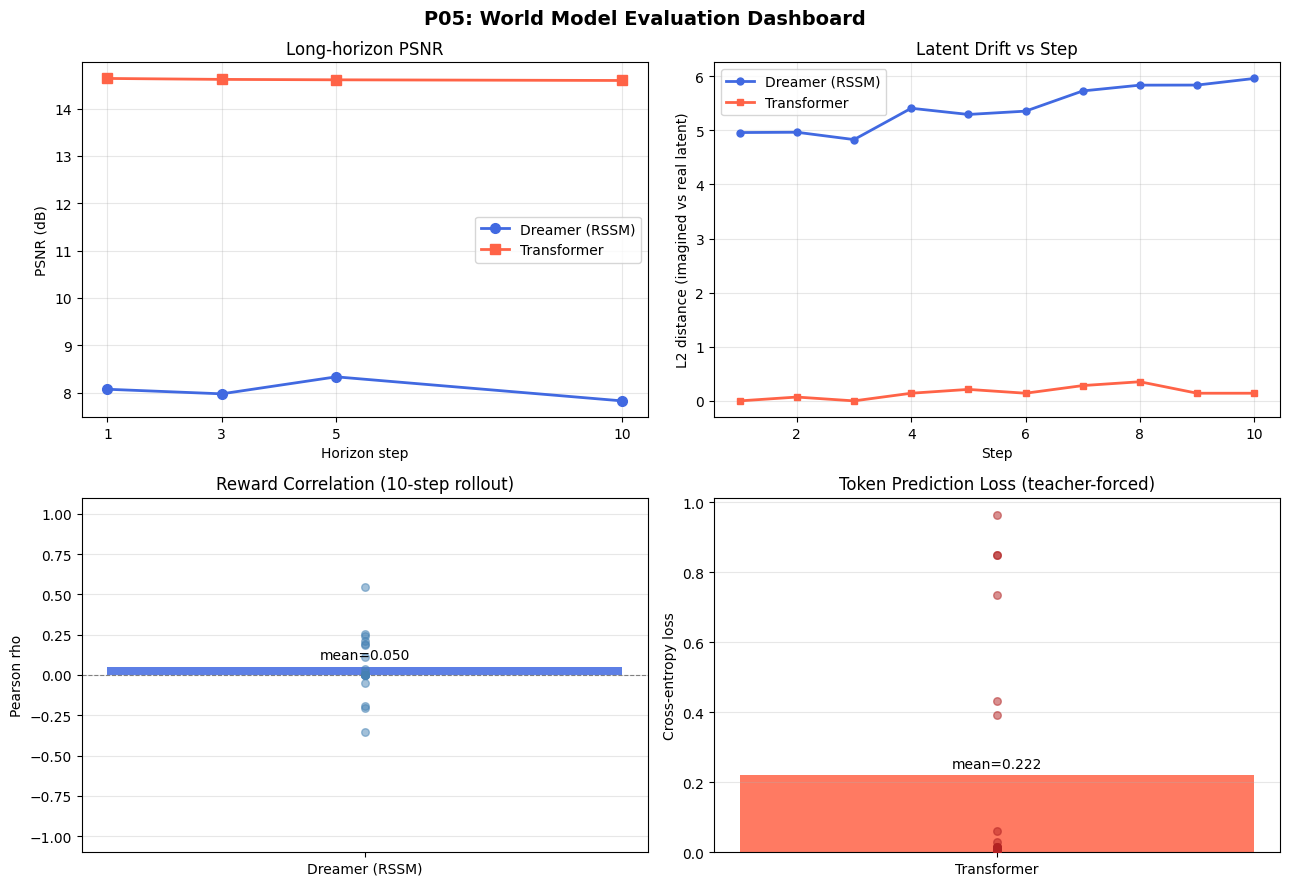

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('P05: World Model Evaluation Dashboard', fontsize=14, fontweight='bold')

# Plot 1: PSNR vs horizon.
ax = axes[0, 0]
d_psnr_vals = [dreamer_psnr_mean[s] for s in PSNR_STEPS]
t_psnr_vals = [trans_psnr_mean[s]   for s in PSNR_STEPS]
ax.plot(PSNR_STEPS, d_psnr_vals, 'o-', color='royalblue',  linewidth=2, markersize=7, label='Dreamer (RSSM)')
ax.plot(PSNR_STEPS, t_psnr_vals, 's-', color='tomato',     linewidth=2, markersize=7, label='Transformer')
ax.set_xlabel('Horizon step')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Long-horizon PSNR')
ax.set_xticks(PSNR_STEPS)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Latent drift vs step ---
ax = axes[0, 1]
d_drift_vals = [dreamer_drift_mean[s] for s in DRIFT_STEPS]
t_drift_vals = [trans_drift_mean[s]   for s in DRIFT_STEPS]
ax.plot(DRIFT_STEPS, d_drift_vals, 'o-', color='royalblue', linewidth=2, markersize=5, label='Dreamer (RSSM)')
ax.plot(DRIFT_STEPS, t_drift_vals, 's-', color='tomato',    linewidth=2, markersize=5, label='Transformer')
ax.set_xlabel('Step')
ax.set_ylabel('L2 distance (imagined vs real latent)')
ax.set_title('Latent Drift vs Step')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Reward correlation (Dreamer) ---
ax = axes[1, 0]
per_traj_rho = dreamer_rew_corr
ax.bar(['Dreamer (RSSM)'], [dreamer_rho], color='royalblue', alpha=0.85, width=0.4)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylim(-1.1, 1.1)
ax.set_ylabel('Pearson rho')
ax.set_title('Reward Correlation (10-step rollout)')
# Overlay individual trajectory values as scatter
ax.scatter(
    np.zeros(len(per_traj_rho)),
    per_traj_rho, color='steelblue', alpha=0.5, zorder=3, s=30
)
ax.text(0, dreamer_rho + 0.05, f'mean={dreamer_rho:.3f}', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 4: Token prediction loss (Transformer) ---
ax = axes[1, 1]
ax.bar(['Transformer'], [trans_tok_mean], color='tomato', alpha=0.85, width=0.4)
ax.set_ylabel('Cross-entropy loss')
ax.set_title('Token Prediction Loss (teacher-forced)')
ax.scatter(
    np.zeros(len(trans_tok_loss)),
    trans_tok_loss, color='firebrick', alpha=0.5, zorder=3, s=30
)
ax.text(0, trans_tok_mean + 0.02, f'mean={trans_tok_mean:.3f}', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Decoded Frame Sequences: Side-by-Side Visualization

A 3-row image grid compares ground-truth observations with imagined frames from each model
at rollout steps 1, 5, 10, and the final step (step 20, i.e., the last frame of the
trajectory). This makes PSNR degradation visible at a glance.

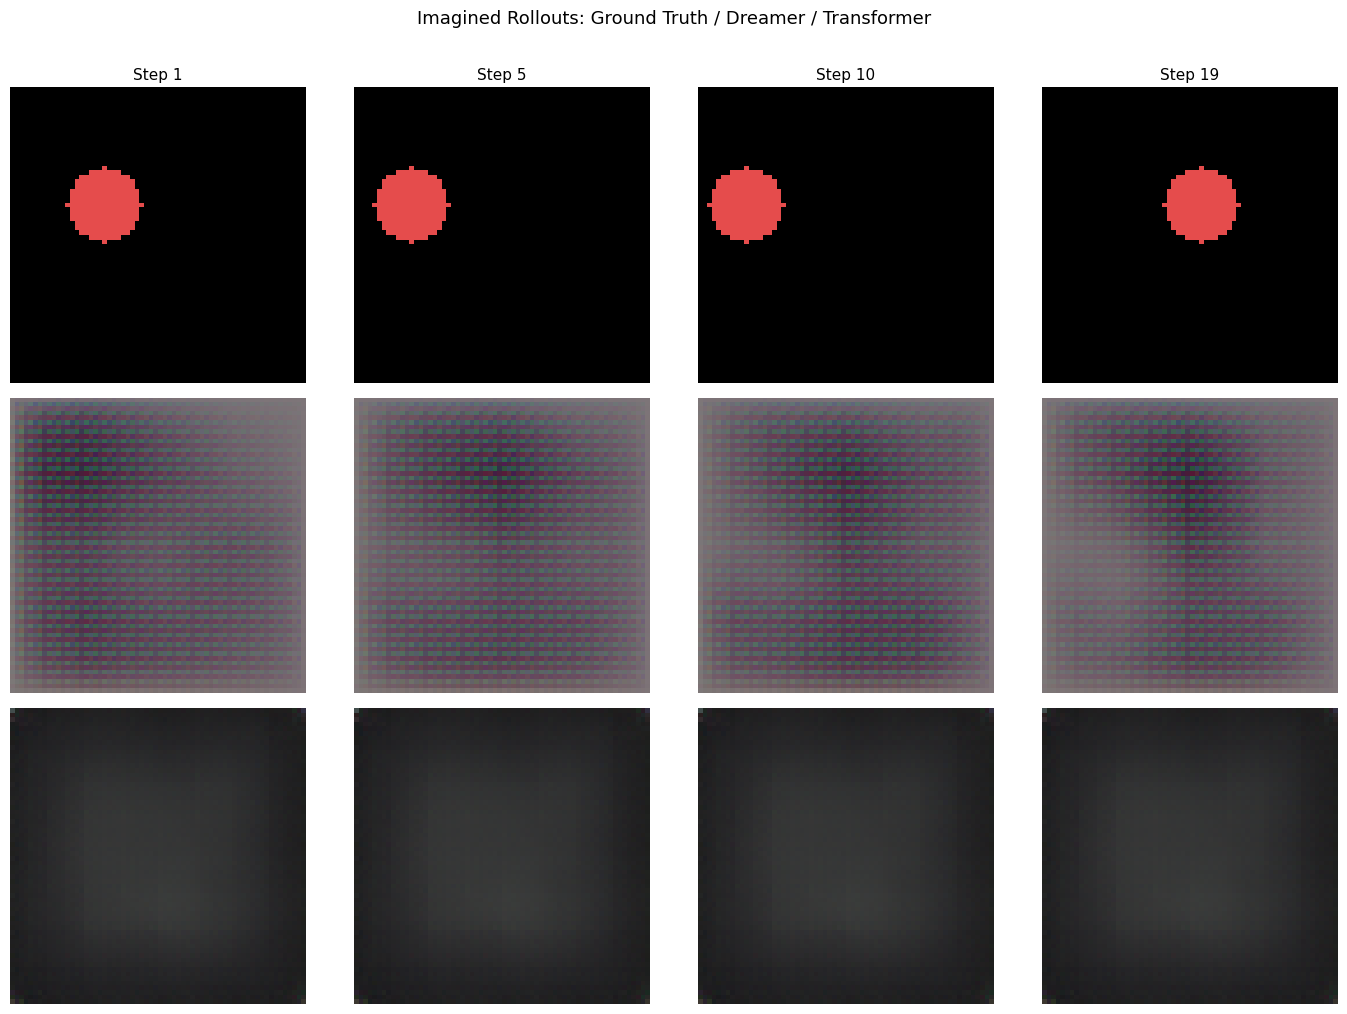

In [12]:
DISPLAY_STEPS = [1, 5, 10, SEQ_LEN - 1]  # 1-indexed except the last
TRAJ_IDX = 0  # use the first evaluation trajectory for visualization

obs_seq_vis = eval_obs[TRAJ_IDX].to(DEVICE)  # (T, 3, 64, 64)
act_seq_vis = eval_act[TRAJ_IDX].to(DEVICE)  # (T,)
T_vis = obs_seq_vis.shape[0]

with torch.no_grad():
    # --- Dreamer imagined frames ---
    h_vis = torch.zeros(1, rssm.hidden_dim, device=DEVICE)
    mu0, _ = encoder.forward(obs_seq_vis[0:1])
    s_vis  = mu0
    dreamer_vis_frames = []
    for t in range(max(DISPLAY_STEPS)):
        a_t = act_seq_vis[t:t+1]
        s_vis, h_vis = rssm.prior_step(h_vis, a_t)
        frame = decoder(torch.cat([h_vis, s_vis], dim=-1))
        dreamer_vis_frames.append(frame.squeeze(0).cpu())

    # --- Transformer imagined frames ---
    logits0  = catvae.encoder(obs_seq_vis[0:1])
    idx0     = logits0.argmax(-1)
    z0_oh    = F.one_hot(idx0, num_classes=N_CATEGORIES).float()  # (1, K)
    z_ctx    = z0_oh.unsqueeze(0)   # (1, 1, K)
    trans_vis_frames = []
    for t in range(max(DISPLAY_STEPS)):
        a_prefix = act_seq_vis[:z_ctx.shape[1]].unsqueeze(0)
        tok_out, _, _ = transformer(z_ctx, a_prefix)
        next_z = F.one_hot(tok_out[0, -1, :].argmax().unsqueeze(0), num_classes=N_CATEGORIES).float()
        frame  = catvae.decoder(next_z)
        trans_vis_frames.append(frame.squeeze(0).cpu())
        z_ctx = torch.cat([z_ctx, next_z.unsqueeze(0)], dim=1)

# --- Build the 3-row grid ---
n_cols = len(DISPLAY_STEPS)
fig, axes = plt.subplots(3, n_cols, figsize=(3.5 * n_cols, 10))
row_labels = ['Ground Truth', 'Dreamer (RSSM)', 'Transformer']

for col, step in enumerate(DISPLAY_STEPS):
    gt_idx = min(step - 1, T_vis - 1) if step >= 1 else step
    gt_frame = obs_seq_vis[gt_idx].cpu().permute(1, 2, 0).numpy()

    dream_frame = dreamer_vis_frames[step - 1].permute(1, 2, 0).numpy()
    trans_frame = trans_vis_frames[step - 1].permute(1, 2, 0).numpy()

    for row, (frame, label) in enumerate(zip(
            [gt_frame, dream_frame, trans_frame], row_labels)):
        ax = axes[row, col]
        ax.imshow(np.clip(frame, 0, 1))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label, fontsize=11)
        if row == 0:
            ax.set_title(f'Step {step}', fontsize=11)

plt.suptitle('Imagined Rollouts: Ground Truth / Dreamer / Transformer', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Diagnostic Summary

Summarize the main failure modes and tradeoffs.

### PSNR degradation

PSNR falls with horizon for both models because neither has access to future observations
during imagination. The RSSM's continuous Gaussian stochastic state smoothly interpolates
between frames, which tends to produce blurrier but metrically closer reconstructions at
short horizons. The Transformer's discrete token bottleneck is sharper at step 1 when the
seed token is reliable, but error compounds rapidly: each incorrect predicted token becomes
the context for the next. If a checkpoint is missing, the fallback path uses random weights,
which is useful for smoke testing but not for comparing shipped metrics.

### Latent drift and compounding errors

Latent drift (L2 distance between imagined and real latent vectors) grows monotonically with
step for both architectures. In the RSSM, the GRU's recurrence introduces a smoothing bias:
the hidden state drifts gradually rather than jumping discontinuously. In the Transformer,
drift is often larger because a single misclassified token changes the entire context window,
which then biases all subsequent predictions. This is the compounding-error problem that
DreamerV3 addresses by mixing prior and posterior during training.

### Reward correlation as an RSSM-specific metric

Reward correlation is defined only for the Dreamer model because the RSSM has a dedicated
reward head trained end-to-end with the actor-critic loss. The Transformer predicts rewards
as a side-task but was not trained with a policy gradient signal, so its reward predictions
are not used for planning and are excluded from this metric.

### Teacher-forcing gap

Token prediction loss is measured under teacher forcing: the model receives ground-truth
tokens as context at every step. At inference time the model must condition on its own
previous predictions, which introduces a distribution shift. The gap between teacher-forced
loss and open-loop PSNR reveals the magnitude of this shift. Larger gaps indicate that the
model has overfit to ground-truth context and will degrade more sharply in free rollout.

In [13]:
# Final inline summary table.
print('=' * 90)
print('P05 FINAL METRICS SUMMARY')
print('=' * 90)
header2 = (
    f"{'Model':<14} | "
    f"{'PSNR@1':>8} | "
    f"{'PSNR@5':>8} | "
    f"{'PSNR@10':>9} | "
    f"{'LatentDrift@10':>14} | "
    f"{'RewardCorr':>11} | "
    f"{'TokenLoss':>10}"
)
sep2 = '-' * len(header2)
print(header2)
print(sep2)
print(
    f"{'Dreamer':<14} | "
    f"{dreamer_psnr_mean[1]:>8.2f} | "
    f"{dreamer_psnr_mean[5]:>8.2f} | "
    f"{dreamer_psnr_mean[10]:>9.2f} | "
    f"{dreamer_drift_mean[10]:>14.4f} | "
    f"{dreamer_rho:>11.4f} | "
    f"{'N/A':>10}"
)
print(
    f"{'Transformer':<14} | "
    f"{trans_psnr_mean[1]:>8.2f} | "
    f"{trans_psnr_mean[5]:>8.2f} | "
    f"{trans_psnr_mean[10]:>9.2f} | "
    f"{trans_drift_mean[10]:>14.4f} | "
    f"{'N/A':>11} | "
    f"{trans_tok_mean:>10.4f}"
)
print(sep2)
print()
print('Notes:')
print('  PSNR in dB (higher is better); Latent Drift in L2 norm (lower is better)')
print('  RewardCorr: Pearson rho over 10-step imagined rollout (Dreamer only)')
print('  TokenLoss: cross-entropy under teacher forcing (Transformer only)')
print(f'  Models loaded from checkpoint: Dreamer={dreamer_loaded}, Transformer={trans_loaded}')

P05 FINAL METRICS SUMMARY
Model          |   PSNR@1 |   PSNR@5 |   PSNR@10 | LatentDrift@10 |  RewardCorr |  TokenLoss
--------------------------------------------------------------------------------------------
Dreamer        |     8.07 |     8.33 |      7.83 |         5.9595 |      0.0496 |        N/A
Transformer    |    14.64 |    14.61 |     14.59 |         0.1414 |         N/A |     0.2220
--------------------------------------------------------------------------------------------

Notes:
  PSNR in dB (higher is better); Latent Drift in L2 norm (lower is better)
  RewardCorr: Pearson rho over 10-step imagined rollout (Dreamer only)
  TokenLoss: cross-entropy under teacher forcing (Transformer only)
  Models loaded from checkpoint: Dreamer=True, Transformer=True
